In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from typing import Tuple, Optional, Callable

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"font.size": 11, "figure.figsize": (10, 4), "figure.dpi": 100})
torch.manual_seed(42)
np.random.seed(42)

In [10]:
def compute_normalization(x: torch.Tensor, mu: torch.Tensor, var: torch.Tensor, eps: float) -> Tuple[torch.Tensor, torch.Tensor]:
    """Helper function for standard normalization step.

    Args:
        x: Input tensor.
        mu: Mean tensor.
        var: Variance tensor.
        eps: Small value to prevent division by zero.

    Returns:
        x_hat: Normalized tensor.
        inv_std: Inverse standard deviation.
    """
    inv_std = 1.0 / torch.sqrt(var + eps)
    x_hat = (x - mu) * inv_std
    return x_hat, inv_std


---
# 1) Normalization Techniques

Normalization layers stabilize the distribution of activations at each layer, enabling training of much deeper networks.

## 1.1 Batch Normalization

**Internal covariate shift** (Ioffe & Szegedy, 2015): as training updates earlier layers, the distribution of inputs to later layers changes. Each layer must continuously adapt to a moving input distribution.

BatchNorm addresses this by normalizing the inputs to each layer to have zero mean and unit variance (computed over the mini-batch), then rescaling with learnable parameters.

> **Note:** The original "internal covariate shift" explanation has been challenged. More recent analysis (Santurkar et al., 2018) suggests BatchNorm works primarily by **smoothing the loss landscape**, making optimization easier. The normalization reduces sensitivity to learning rate and initialization.

In [11]:
class BatchNorm1d:
    """Batch Normalization for fully-connected layers, from scratch."""

    def __init__(self, num_features: int, momentum: float = 0.1, eps: float = 1e-5):
        self.num_features = num_features
        self.momentum = momentum
        self.eps = eps

        # Learnable parameters
        # (num_features,)
        self.gamma = torch.ones(num_features)
        self.beta = torch.zeros(num_features)

        # Running statistics for inference
        # (num_features,)
        self.running_mean = torch.zeros(num_features)
        self.running_var = torch.ones(num_features)

        # Cache for backward pass
        self.cache = {}

    def forward(self, x: torch.Tensor, training: bool = True) -> torch.Tensor:
        """BatchNorm forward pass.

        Args:
            x: (batch_num, num_features)
        Returns:
            out: (batch_num, num_features)
        """
        if training:
            # Compute batch statistics
            # (num_features,)
            mu = x.mean(dim=0)
            # (num_features,)
            var = x.var(dim=0, unbiased=False)

            # Normalize using modular function
            x_hat, inv_std = compute_normalization(x, mu, var, self.eps)

            # Update running statistics
            self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * mu.detach()
            self.running_var = (1 - self.momentum) * self.running_var + self.momentum * var.detach()

            # Cache for backward
            self.cache = {"x": x, "x_hat": x_hat, "mu": mu, "var": var, "inv_std": inv_std}
        else:
            # Use running statistics
            x_hat, inv_std = compute_normalization(x, self.running_mean, self.running_var, self.eps)

        # Scale and shift: (batch_num, num_features)
        return self.gamma * x_hat + self.beta

    def backward(self, grad_output: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """BatchNorm backward pass.

        Args:
            grad_output: (batch_num, num_features) — dL/dy
        Returns:
            grad_input: (batch_num, num_features) — dL/dx
            grad_gamma: (num_features,) — dL/dgamma
            grad_beta: (num_features,) — dL/dbeta
        """
        x, x_hat = self.cache["x"], self.cache["x_hat"]
        mu, var, inv_std = self.cache["mu"], self.cache["var"], self.cache["inv_std"]
        batch_num = x.shape[0]

        # (num_features,)
        grad_gamma = (grad_output * x_hat).sum(dim=0)
        # (num_features,)
        grad_beta = grad_output.sum(dim=0)

        # (batch_num, num_features)
        dx_hat = grad_output * self.gamma

        # (num_features,)
        dvar = (dx_hat * (x - mu) * (-0.5) * (var + self.eps) ** (-1.5)).sum(dim=0)

        # (num_features,)
        dmu = (dx_hat * (-inv_std)).sum(dim=0)

        # (batch_num, num_features)
        grad_input = dx_hat * inv_std + dvar * 2.0 * (x - mu) / batch_num + dmu / batch_num

        return grad_input, grad_gamma, grad_beta


# Test: compare with PyTorch's BatchNorm
batch_num, num_features = 32, 64
x = torch.randn(batch_num, num_features, requires_grad=True)

# Our implementation
bn_custom = BatchNorm1d(num_features)
out_custom = bn_custom.forward(x.detach())

# PyTorch reference
bn_pytorch = torch.nn.BatchNorm1d(num_features)
out_pytorch = bn_pytorch(x)

print(f"Forward pass max error: {(out_custom - out_pytorch.detach()).abs().max().item():.2e}")

# Test backward
grad_out = torch.randn_like(out_custom)
grad_input, grad_gamma, grad_beta = bn_custom.backward(grad_out)

out_pytorch.backward(grad_out)
print(f"Backward pass (dx) max error: {(grad_input - x.grad).abs().max().item():.2e}")


Forward pass max error: 4.77e-07
Backward pass (dx) max error: 7.15e-07


## 1.2 Layer Normalization

**BatchNorm fails when:**
- **Small batch sizes:** Statistics over $B=1$ are meaningless
- **Variable-length sequences:** In NLP, different sequences have different lengths; batch statistics mix different time steps
- **Online/recurrent settings:** Each time step has a different distribution

**LayerNorm** (Ba et al., 2016) normalizes across the **feature dimension** instead of the batch dimension:

$$\mu_i = \frac{1}{D}\sum_{d=1}^{D} x_{i,d}, \quad \sigma_i^2 = \frac{1}{D}\sum_{d=1}^{D}(x_{i,d} - \mu_i)^2$$

$$\hat{x}_{i,d} = \frac{x_{i,d} - \mu_i}{\sqrt{\sigma_i^2 + \epsilon}}, \quad y_{i,d} = \gamma_d \hat{x}_{i,d} + \beta_d$$

Each sample is normalized **independently** — no dependence on other samples in the batch.

In [12]:
class LayerNorm:
    """Layer Normalization from scratch."""

    def __init__(self, normalized_shape: int, eps: float = 1e-5):
        self.normalized_shape = normalized_shape
        self.eps = eps

        # Learnable parameters
        # (normalized_shape,)
        self.gamma = torch.ones(normalized_shape)
        self.beta = torch.zeros(normalized_shape)

        self.cache = {}

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """LayerNorm forward.

        Args:
            x: (*, normalized_shape) — e.g. (batch_num, seq_len, embed_dim)
        Returns:
            out: same shape as x
        """
        # Mean and variance over the last dimension
        # (*, 1)
        mu = x.mean(dim=-1, keepdim=True)
        # (*, 1)
        var = x.var(dim=-1, keepdim=True, unbiased=False)

        # Normalize using modular function
        x_hat, inv_std = compute_normalization(x, mu, var, self.eps)

        self.cache = {"x": x, "x_hat": x_hat, "mu": mu, "var": var, "inv_std": inv_std}

        # Scale and shift: (*, normalized_shape)
        return self.gamma * x_hat + self.beta

    def backward(self, grad_output: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """LayerNorm backward.

        Args:
            grad_output: same shape as forward output
        Returns:
            grad_input, grad_gamma, grad_beta
        """
        x, x_hat = self.cache["x"], self.cache["x_hat"]
        mu, var, inv_std = self.cache["mu"], self.cache["var"], self.cache["inv_std"]
        D = self.normalized_shape

        # (normalized_shape,) — sum over all dims except the last
        grad_gamma = (grad_output * x_hat).reshape(-1, D).sum(dim=0)
        grad_beta = grad_output.reshape(-1, D).sum(dim=0)

        # (*, normalized_shape)
        dx_hat = grad_output * self.gamma

        # (*, 1)
        dvar = (dx_hat * (x - mu) * (-0.5) * (var + self.eps) ** (-1.5)).sum(dim=-1, keepdim=True)

        # (*, 1)
        dmu = (dx_hat * (-inv_std)).sum(dim=-1, keepdim=True)

        # (*, normalized_shape)
        grad_input = dx_hat * inv_std + dvar * 2.0 * (x - mu) / D + dmu / D

        return grad_input, grad_gamma, grad_beta


# Test against PyTorch
batch_num, seq_len, embed_dim = 4, 8, 32
x = torch.randn(batch_num, seq_len, embed_dim, requires_grad=True)

ln_custom = LayerNorm(embed_dim)
out_custom = ln_custom.forward(x.detach())

ln_pytorch = torch.nn.LayerNorm(embed_dim, elementwise_affine=True)
out_pytorch = ln_pytorch(x)

print(f"LayerNorm forward max error: {(out_custom - out_pytorch.detach()).abs().max().item():.2e}")

grad_out = torch.randn_like(out_custom)
grad_input, _, _ = ln_custom.backward(grad_out)
out_pytorch.backward(grad_out)
print(f"LayerNorm backward (dx) max error: {(grad_input - x.grad).abs().max().item():.2e}")


LayerNorm forward max error: 4.77e-07
LayerNorm backward (dx) max error: 4.77e-07


## 1.3 RMSNorm

**RMSNorm** (Zhang & Sennrich, 2019) removes the mean-centering step from LayerNorm, using only the root-mean-square for normalization:

$$\text{RMS}(x) = \sqrt{\frac{1}{D}\sum_{d=1}^{D} x_d^2}$$

$$\hat{x}_d = \frac{x_d}{\text{RMS}(x)}, \quad y_d = \gamma_d \hat{x}_d$$

Note: RMSNorm typically has no bias ($\beta$) term.

**Key insight:** The main benefit of normalization comes from **re-scaling** (dividing by a norm), not from **re-centering** (subtracting the mean). Empirically, removing the mean has negligible impact on performance while saving computation:

- LayerNorm: 2 reductions (mean + variance) + 2 elementwise ops
- RMSNorm: 1 reduction (RMS) + 1 elementwise op

This makes RMSNorm ~7-10% faster than LayerNorm, which matters at scale. Used in LLaMA, Gemma, and most modern LLMs.

**Gradient derivation:**

Let $r = \text{RMS}(x) = \sqrt{\frac{1}{D}\sum x_d^2 + \epsilon}$.

$$\frac{\partial y_d}{\partial x_j} = \gamma_d \left(\frac{\delta_{dj}}{r} - \frac{x_d x_j}{D r^3}\right)$$

In [6]:
class RMSNorm:
    """Root Mean Square Normalization from scratch."""

    def __init__(self, normalized_shape: int, eps: float = 1e-8):
        self.normalized_shape = normalized_shape
        self.eps = eps
        # (normalized_shape,)
        self.gamma = torch.ones(normalized_shape)
        self.cache = {}

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """RMSNorm forward.

        Args:
            x: (*, normalized_shape)
        Returns:
            out: same shape as x
        """
        # (*, 1)
        rms = torch.sqrt((x ** 2).mean(dim=-1, keepdim=True) + self.eps)
        # (*, normalized_shape)
        x_hat = x / rms

        self.cache = {"x": x, "x_hat": x_hat, "rms": rms}

        # (*, normalized_shape)
        return self.gamma * x_hat

    def backward(self, grad_output: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """RMSNorm backward.

        Args:
            grad_output: same shape as forward output
        Returns:
            grad_input, grad_gamma
        """
        x, x_hat, rms = self.cache["x"], self.cache["x_hat"], self.cache["rms"]
        D = self.normalized_shape

        # (normalized_shape,)
        grad_gamma = (grad_output * x_hat).reshape(-1, D).sum(dim=0)

        # (*, normalized_shape)
        dx_hat = grad_output * self.gamma

        # Gradient through the RMS normalization
        # (*, normalized_shape)
        grad_input = (dx_hat - x_hat * (dx_hat * x_hat).sum(dim=-1, keepdim=True) / D) / rms

        return grad_input, grad_gamma


# Test: verify with autograd
batch_num, embed_dim = 8, 64
x = torch.randn(batch_num, embed_dim, requires_grad=True)

rms_custom = RMSNorm(embed_dim)
out_custom = rms_custom.forward(x.detach())

# Manual autograd check
x_ag = x.clone().detach().requires_grad_(True)
rms_val = torch.sqrt((x_ag ** 2).mean(dim=-1, keepdim=True) + 1e-8)
out_ag = x_ag / rms_val

grad_out = torch.randn_like(out_custom)
out_ag.backward(grad_out)

grad_input, _ = rms_custom.backward(grad_out)
print(f"RMSNorm forward max error: {(out_custom - out_ag.detach()).abs().max().item():.2e}")
print(f"RMSNorm backward (dx) max error: {(grad_input - x_ag.grad).abs().max().item():.2e}")

RMSNorm forward max error: 0.00e+00
RMSNorm backward (dx) max error: 2.38e-07


## 1.4 Group Normalization

**Group Normalization** (Wu & He, 2018) bridges BatchNorm and LayerNorm:

- **BatchNorm:** normalizes over $(B, H, W)$ per channel — fails with small batches
- **LayerNorm:** normalizes over $(C, H, W)$ per sample — doesn't exploit channel groupings
- **GroupNorm:** divides $C$ channels into $G$ groups and normalizes over $(C/G, H, W)$ per group per sample

| Norm | Normalizes Over | Depends on Batch? |
|------|----------------|-------------------|
| BatchNorm | $N, H, W$ | Yes |
| LayerNorm | $C, H, W$ | No |
| InstanceNorm | $H, W$ | No |
| GroupNorm | $C/G, H, W$ | No |

GroupNorm is equivalent to LayerNorm when $G=1$ and to InstanceNorm when $G=C$.

In [13]:
class GroupNorm:
    """Group Normalization from scratch (for 1D features or 2D feature maps)."""

    def __init__(self, num_groups: int, num_channels: int, eps: float = 1e-5):
        assert num_channels % num_groups == 0, "num_channels must be divisible by num_groups"
        self.num_groups = num_groups
        self.num_channels = num_channels
        self.eps = eps

        # (num_channels,)
        self.gamma = torch.ones(num_channels)
        self.beta = torch.zeros(num_channels)
        self.cache = {}

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """GroupNorm forward.

        Args:
            x: (batch_num, num_channels) or (batch_num, num_channels, H, W)
        Returns:
            out: same shape as x
        """
        orig_shape = x.shape
        batch_num = x.shape[0]
        channels_per_group = self.num_channels // self.num_groups

        # Reshape to isolate groups
        if x.dim() == 2:
            # (batch_num, num_groups, channels_per_group)
            x_grouped = x.reshape(batch_num, self.num_groups, channels_per_group)
        else:
            spatial = x.shape[2:]
            # (batch_num, num_groups, channels_per_group, *spatial)
            x_grouped = x.reshape(batch_num, self.num_groups, channels_per_group, *spatial)

        # Normalize over all dims within each group (dims 2+)
        reduce_dims = tuple(range(2, x_grouped.dim()))

        # (batch_num, num_groups, 1, ...)
        mu = x_grouped.mean(dim=reduce_dims, keepdim=True)
        var = x_grouped.var(dim=reduce_dims, keepdim=True, unbiased=False)

        # Normalize using modular function
        x_hat_grouped, inv_std = compute_normalization(x_grouped, mu, var, self.eps)

        # Reshape back
        x_hat = x_hat_grouped.reshape(orig_shape)

        self.cache = {
            "x_grouped": x_grouped, "mu": mu, "var": var,
            "inv_std": inv_std, "x_hat": x_hat, "orig_shape": orig_shape,
            "reduce_dims": reduce_dims,
        }

        # Scale and shift (broadcast gamma, beta over batch and spatial dims)
        if x.dim() == 2:
            return self.gamma * x_hat + self.beta
        else:
            gamma = self.gamma.reshape(1, -1, *([1] * len(spatial)))
            beta = self.beta.reshape(1, -1, *([1] * len(spatial)))
            return gamma * x_hat + beta


# Test GroupNorm
batch_num, num_channels = 8, 32
num_groups = 4

x = torch.randn(batch_num, num_channels)
gn_custom = GroupNorm(num_groups, num_channels)
out_custom = gn_custom.forward(x)

gn_pytorch = torch.nn.GroupNorm(num_groups, num_channels)
out_pytorch = gn_pytorch(x)

print(f"GroupNorm forward max error: {(out_custom - out_pytorch.detach()).abs().max().item():.2e}")

# Test with 4D input (images)
x_4d = torch.randn(4, 16, 8, 8)
gn_custom_4d = GroupNorm(4, 16)
gn_pytorch_4d = torch.nn.GroupNorm(4, 16)
out_4d_custom = gn_custom_4d.forward(x_4d)
out_4d_pytorch = gn_pytorch_4d(x_4d)
print(f"GroupNorm 4D forward max error: {(out_4d_custom - out_4d_pytorch.detach()).abs().max().item():.2e}")


GroupNorm forward max error: 3.58e-07
GroupNorm 4D forward max error: 4.77e-07


## 1.5 Comparison

Consider a 4D tensor `(batch_num, num_channels, H, W)`. Each normalization computes statistics over different dimensions:

```
                    Batch Norm      Layer Norm      Instance Norm    Group Norm
                    ──────────      ──────────      ─────────────    ──────────
Batch dimension:      ████             .                .               .
Channel dimension:      .            ████               .             ██ ██
Spatial (H, W):       ████           ████             ████            ████
                    ──────────      ──────────      ─────────────    ──────────
                    Per channel     Per sample      Per channel      Per group
                    across batch    all channels    per sample       per sample
```

The shaded (████) dimensions are the ones over which statistics (mean, variance) are computed.

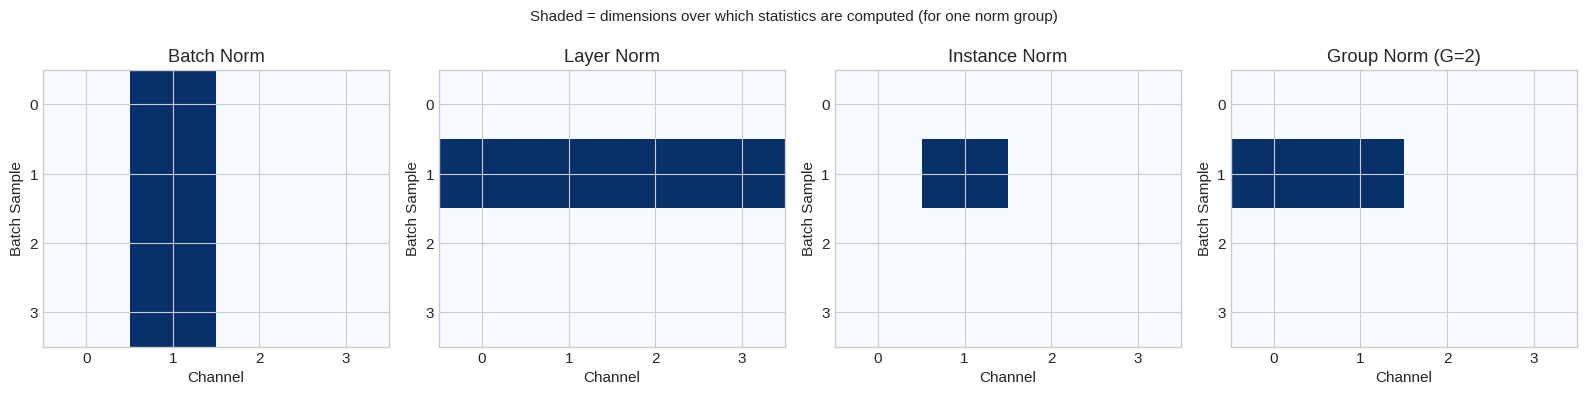

In [8]:
# Visualize which elements contribute to each sample's normalization
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = ["Batch Norm", "Layer Norm", "Instance Norm", "Group Norm (G=2)"]
batch_num, num_channels, H, W = 4, 4, 3, 3

for ax, title in zip(axes, titles):
    grid = np.zeros((batch_num, num_channels))

    if title == "Batch Norm":
        grid[:, 1] = 1  # All batch elements, single channel
    elif title == "Layer Norm":
        grid[1, :] = 1  # Single batch element, all channels
    elif title == "Instance Norm":
        grid[1, 1] = 1  # Single batch element, single channel
    elif "Group" in title:
        grid[1, :2] = 1  # Single batch element, one group of channels

    ax.imshow(grid, cmap="Blues", aspect="auto", vmin=0, vmax=1)
    ax.set_xlabel("Channel")
    ax.set_ylabel("Batch Sample")
    ax.set_title(title)
    ax.set_xticks(range(num_channels))
    ax.set_yticks(range(batch_num))

plt.suptitle("Shaded = dimensions over which statistics are computed (for one norm group)", fontsize=11)
plt.tight_layout()
plt.show()

| Architecture | Recommended Norm | Why |
|-------------|-----------------|-----|
| **CNNs (large batch)** | BatchNorm | Exploits batch statistics; well-calibrated for images |
| **CNNs (small batch / detection)** | GroupNorm | Batch-independent; stable with batch size 1-2 |
| **Transformers (NLP)** | LayerNorm / RMSNorm | Sequence lengths vary; batch stats meaningless |
| **Modern LLMs (LLaMA, Gemma)** | RMSNorm | Faster than LayerNorm; re-centering unnecessary |
| **Style transfer** | InstanceNorm | Per-sample, per-channel normalization for style |
| **RNNs / LSTMs** | LayerNorm | Recurrent structure → batch stats unstable |

In [9]:
# Empirical comparison: effect of batch size on different norms
hidden_dim = 128

def measure_norm_consistency(norm_cls, batch_sizes, **kwargs):
    """Measure how consistent norm outputs are across different batch sizes."""
    std_devs = []
    # Use a fixed input sample to track
    x_fixed = torch.randn(1, hidden_dim)
    outputs = []

    for bs in batch_sizes:
        # (batch_num, hidden_dim)
        x_batch = torch.cat([x_fixed, torch.randn(bs - 1, hidden_dim)], dim=0)
        norm = norm_cls(**kwargs)
        out = norm.forward(x_batch)
        outputs.append(out[0].detach())  # Output for the fixed sample

    # Measure variance of outputs across different batch sizes
    outputs = torch.stack(outputs)
    return outputs.std(dim=0).mean().item()


batch_sizes = [2, 4, 8, 16, 32, 64, 128]

bn_consistency = []
ln_consistency = []
for _ in range(10):
    bn_consistency.append(
        measure_norm_consistency(BatchNorm1d, batch_sizes, num_features=hidden_dim)
    )
    ln_consistency.append(
        measure_norm_consistency(LayerNorm, batch_sizes, normalized_shape=hidden_dim)
    )

print(f"BatchNorm output variability across batch sizes: {np.mean(bn_consistency):.4f} ± {np.std(bn_consistency):.4f}")
print(f"LayerNorm output variability across batch sizes: {np.mean(ln_consistency):.4f} ± {np.std(ln_consistency):.4f}")
print("\nLayerNorm output is ~batch-independent; BatchNorm varies significantly.")

BatchNorm output variability across batch sizes: 0.4238 ± 0.0179
LayerNorm output variability across batch sizes: 0.0000 ± 0.0000

LayerNorm output is ~batch-independent; BatchNorm varies significantly.


---
# Summary
- BatchNorm: powerful for CNNs with large batches
- LayerNorm: batch-independent, standard for Transformers
- RMSNorm: simplified LayerNorm, standard for modern LLMs
- GroupNorm: compromise for small-batch vision tasks